# Phase 2: RemoteCLIP with Difference Fusion

This ablation changes only the Phase 1 visual encoder. It keeps absolute-difference fusion, the existing Transformer caption decoder, and caption cross-entropy loss.

In [1]:
import os
from pathlib import Path
import torch

from src.config import DataConfig, ModelConfig, RemoteCLIPConfig, TrainConfig
from src.dataset import build_remoteclip_transforms, get_levircc_loaders
from src.metrics import SentenceEmbeddingScorer, evaluate_model_on_loader
from src.models.variants import RemoteCLIPDifferenceModel
from src.training import (
    build_criterion, build_optimizer_and_scheduler, load_checkpoint,
    save_checkpoint, train_epoch, validate, visualize_predictions,
)
from src.utils import get_device, set_seed, setup_project_path

PROJECT_ROOT = setup_project_path()
data_cfg = DataConfig(batch_size=8, val_batch_size=16)
model_cfg = ModelConfig()
remoteclip_cfg = RemoteCLIPConfig()
train_cfg = TrainConfig()
RESEARCHER_NAME = 'researcher2_remoteclip_difference'

# execute.sh defaults this environment variable to 1. Set it to 0 when the
# official checkpoint is already at checkpoints/RemoteCLIP-ViT-B-32.pt.
remoteclip_cfg.download_if_missing = os.environ.get(
    'REMOTECLIP_DOWNLOAD_IF_MISSING', '0'
).strip().lower() in {'1', 'true', 'yes'}

set_seed(train_cfg.seed)
device = get_device()
data_cfg.checkpoint_dir.mkdir(exist_ok=True)
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {device}')

/home2/sankalp0109/src_IS/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:262: UserWarning: 
    Found GPU0 NVIDIA GeForce GTX 1080 Ti which is of cuda capability 6.1.
    PyTorch no longer supports this GPU because it is too old.
    The minimum cuda capability supported by this library is 7.5.
    
  warnings.warn(
/home2/sankalp0109/src_IS/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:287: UserWarning: 
NVIDIA GeForce GTX 1080 Ti with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_75 sm_80 sm_86 sm_90 sm_100 sm_120 compute_120.
If you want to use the NVIDIA GeForce GTX 1080 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Project root: /home2/sankalp0109/src_IS
Device: cpu


/home2/sankalp0109/src_IS/src/utils.py:54: RuntimeWarning: CUDA initialized but cannot execute kernels on this GPU; falling back to CPU. Original error: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

  warnings.warn(


## Load LEVIR-CC with RemoteCLIP preprocessing

In [2]:
remoteclip_transform = build_remoteclip_transforms(
    img_size=remoteclip_cfg.image_size,
    mean=remoteclip_cfg.image_mean,
    std=remoteclip_cfg.image_std,
)
train_loader, val_loader, test_loader, vocab = get_levircc_loaders(
    caption_json=data_cfg.caption_json,
    image_root=data_cfg.image_root,
    batch_size=data_cfg.batch_size,
    val_batch_size=data_cfg.val_batch_size,
    device=str(device),
    min_word_freq=data_cfg.min_word_freq,
    caption_index=data_cfg.caption_index,
    num_workers=data_cfg.num_workers,
    vocab_path=data_cfg.vocab_path,
    transforms_fn=remoteclip_transform,
)
print(f'Vocabulary size: {len(vocab.word2idx)}')
print(f'Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Vocabulary size: 733
Train: 852 | Val: 84 | Test: 121


## Build Phase 2 model

In [3]:
model = RemoteCLIPDifferenceModel(
    vocab_size=len(vocab.word2idx),
    encoder_dim=remoteclip_cfg.encoder_dim,
    embed_dim=model_cfg.embed_dim,
    num_heads=model_cfg.num_heads,
    num_decoder_layers=model_cfg.num_decoder_layers,
    max_caption_len=model_cfg.max_caption_len,
    dropout=model_cfg.dropout,
    pad_idx=vocab.pad_idx,
    remoteclip_model_name=remoteclip_cfg.model_name,
    remoteclip_checkpoint_path=remoteclip_cfg.checkpoint_path,
    freeze_remoteclip=remoteclip_cfg.freeze_backbone,
    download_if_missing=remoteclip_cfg.download_if_missing,
    remoteclip_repo_id=remoteclip_cfg.hf_repo_id,
    fusion_dropout=remoteclip_cfg.fusion_dropout,
).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Model: {model.model_name}')
print(f'Trainable parameters: {trainable:,} / {total:,}')

Model: RemoteCLIPDifferenceModel
Trainable parameters: 3,427,805 / 154,705,118


## Train with the unchanged captioning objective

In [4]:
criterion = build_criterion(vocab)
optimizer, scheduler = build_optimizer_and_scheduler(model, train_cfg)
current_path = data_cfg.checkpoint_dir / f'{RESEARCHER_NAME}_current.pt'
best_path = data_cfg.checkpoint_dir / f'{RESEARCHER_NAME}_best.pt'
best_val_loss = float('inf')
start_epoch = 1

if current_path.exists():
    model, optimizer, last_epoch, loaded_vocab, loaded_loss = load_checkpoint(
        model, optimizer, current_path, device
    )
    start_epoch = last_epoch + 1
    if loaded_loss is not None:
        best_val_loss = loaded_loss

for epoch in range(start_epoch, train_cfg.num_epochs + 1):
    train_loss = train_epoch(
        model, train_loader, criterion, optimizer, device,
        pad_idx=vocab.pad_idx, grad_clip=train_cfg.grad_clip,
        log_every=train_cfg.log_every,
    )
    val_loss, val_accuracy = validate(
        model, val_loader, criterion, device,
        pad_idx=vocab.pad_idx, return_accuracy=True,
    )
    scheduler.step()
    print(f'Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}, token_acc={val_accuracy:.4f}')
    save_checkpoint(
        model, optimizer, epoch, val_loss, vocab, data_cfg.checkpoint_dir,
        filename=current_path.name,
        extra={'phase': 2, 'encoder': remoteclip_cfg.model_name, 'fusion': 'absolute_difference'},
    )
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            model, optimizer, epoch, val_loss, vocab, data_cfg.checkpoint_dir,
            filename=best_path.name,
            extra={'phase': 2, 'encoder': remoteclip_cfg.model_name, 'fusion': 'absolute_difference'},
        )

  Batch 10/852: loss = 5.7595


  Batch 20/852: loss = 5.1780


  Batch 30/852: loss = 4.8916


  Batch 40/852: loss = 4.5376


  Batch 50/852: loss = 4.2312


...

  Batch 830/852: loss = 0.7194


  Batch 840/852: loss = 0.7193


  Batch 850/852: loss = 0.7161


Epoch 10: train=0.7164, val=1.0545, token_acc=0.7379


Checkpoint saved: checkpoints/researcher2_remoteclip_difference_current.pt


## Evaluate Phase 2

Test loss: 0.9345


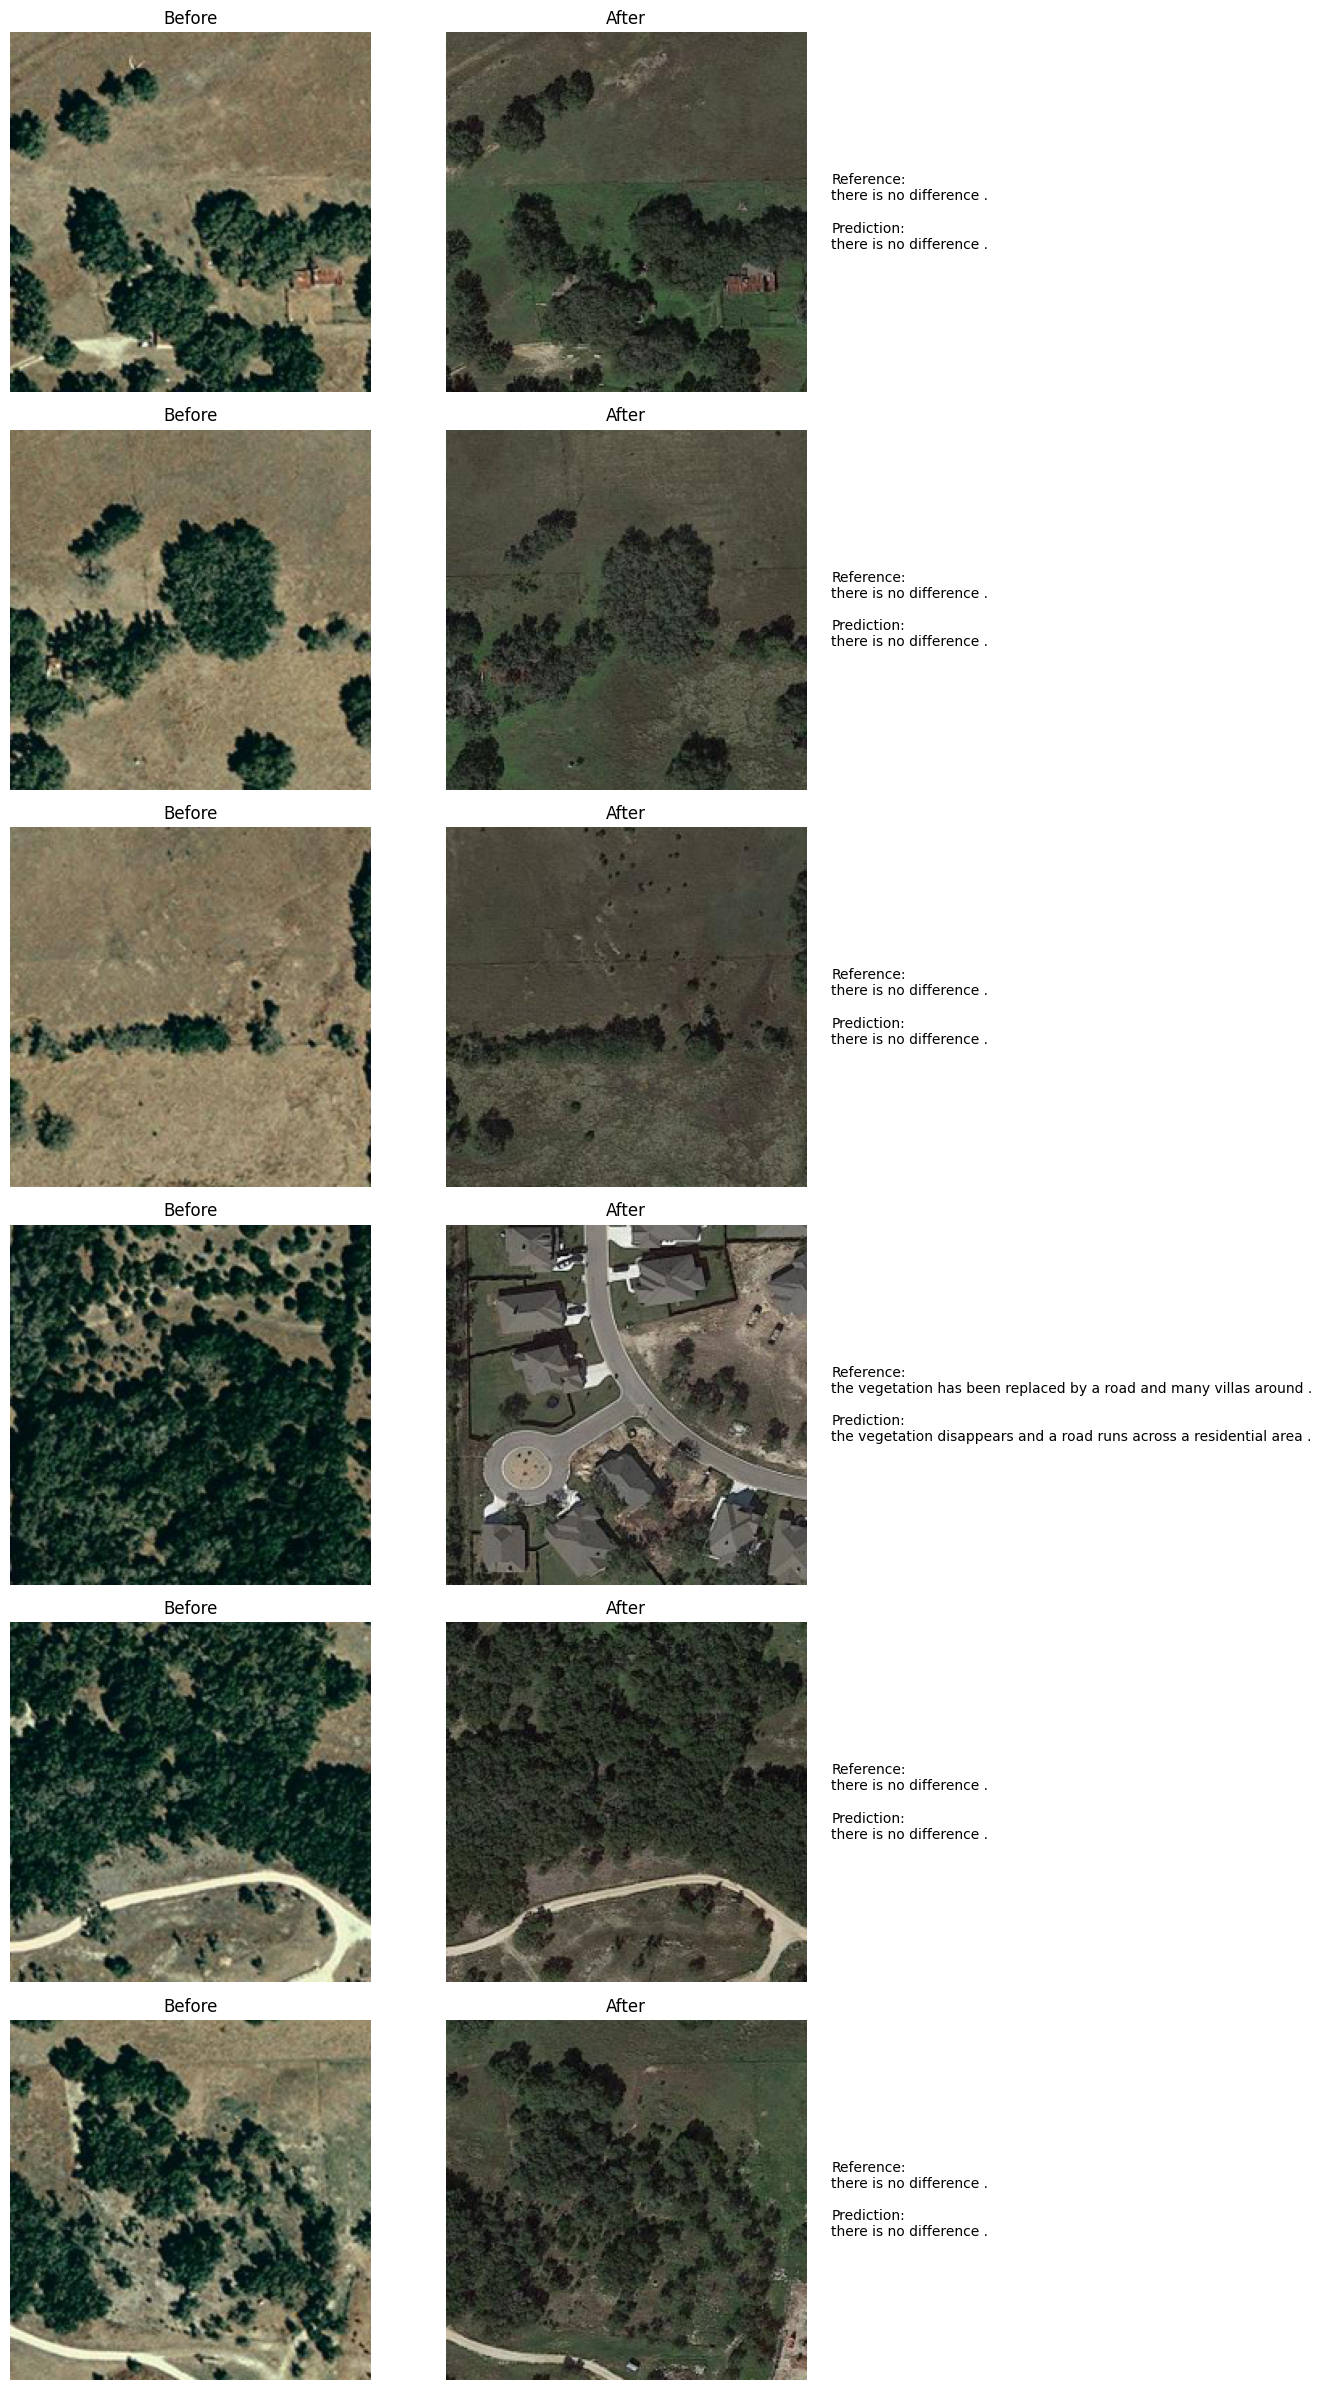

BLEU-1: 0.5168
BLEU-2: 0.4237
BLEU-3: 0.3712
BLEU-4: 0.3284
METEOR: 0.6304
ROUGE-L: 0.6545
CIDEr: 5.3469
Semantic-Similarity: 0.7061
num_samples: 1929


In [ ]:
test_loss = validate(model, test_loader, criterion, device, pad_idx=vocab.pad_idx)
print(f'Test loss: {test_loss:.4f}')
visualize_predictions(
    model,
    test_loader,
    vocab,
    device,
    num_samples=300,
    output_pdf="predictions_remoteclip.pdf",
    mean=remoteclip_cfg.image_mean,
    std=remoteclip_cfg.image_std,
)

semantic_scorer = SentenceEmbeddingScorer('all-MiniLM-L6-v2', device=str(device))
metrics, details = evaluate_model_on_loader(
    model, test_loader, vocab, device, semantic_model=semantic_scorer
)
for name, value in metrics.items():
    print(f'{name}: {value:.4f}' if isinstance(value, float) else f'{name}: {value}')